In [5]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import re
import string

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [12]:
import os
print(os.getcwd())

C:\Users\PC\OneDrive\Desktop\FUTURE_ML_01\TASK_03_Resume_Screening_System\notebooks


In [13]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (962, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [14]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [15]:
print("Number of categories:", df["Category"].nunique())
print()

print(df["Category"].unique())

Number of categories: 25

['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [16]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

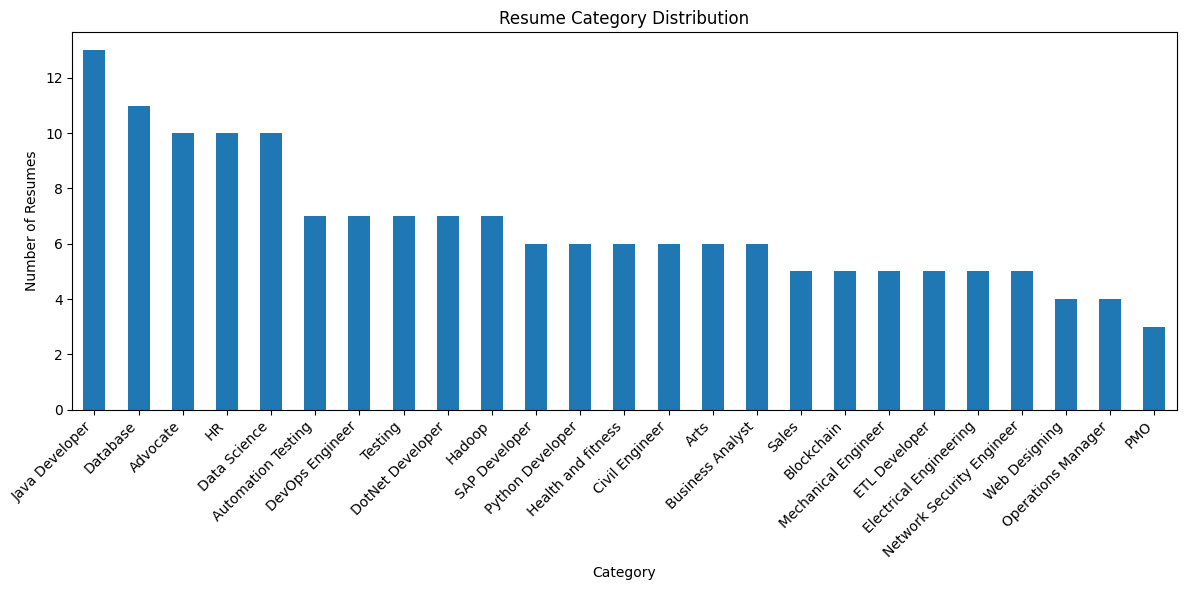

In [64]:
plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/category_distribution.png", dpi=300)

plt.show()


In [18]:
df["Resume_Length"] = df["Resume"].apply(len)

df.head()

,Category,Resume,Resume_Length
0,Data Science,Skills * Programming Languages: Python (pandas...,4786
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,1268
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,6995
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",452


In [19]:
df["Resume_Length"].describe()

count      962.000000
mean      3160.364865
std       2886.528521
min        142.000000
25%       1217.250000
50%       2355.000000
75%       4073.750000
max      14816.000000
Name: Resume_Length, dtype: float64

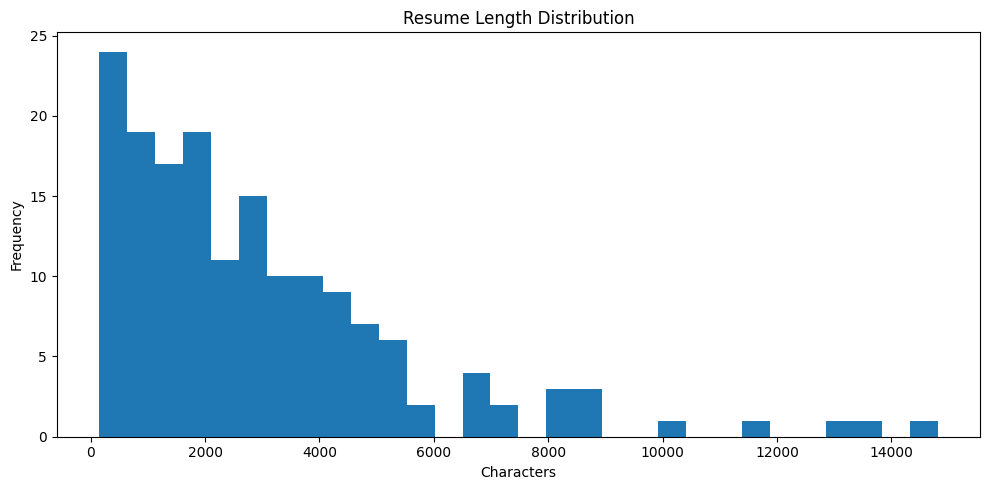

In [59]:
plt.figure(figsize=(10,5))

plt.hist(df["Resume_Length"], bins=30)

plt.title("Resume Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/resume_length_distribution.png", dpi=300)
plt.show()


In [21]:
df.isnull().sum()

Category         0
Resume           0
Resume_Length    0
dtype: int64

In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 796


In [23]:
def clean_resume(text):

    text = text.lower()

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"\d+", " ", text)

    text = re.sub(r"[^\w\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [24]:
df["Clean_Resume"] = df["Resume"].apply(clean_resume)

In [25]:
df[["Resume", "Clean_Resume"]].head()

,Resume,Clean_Resume
0,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Education Details \r\nMay 2013 to May 2017 B.E...,education details may to may b e uit rgpv data...
2,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills â r â python â sap hana â tableau â sap...
4,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


In [26]:
df = df.drop_duplicates()

print("Dataset shape:", df.shape)

Dataset shape: (166, 4)


In [27]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [28]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

resume_vectors = tfidf.fit_transform(df["Clean_Resume"])

print("TF-IDF Matrix Shape:", resume_vectors.shape)

TF-IDF Matrix Shape: (166, 5000)


In [29]:
similarity_matrix = cosine_similarity(resume_vectors)

print(similarity_matrix.shape)

(166, 166)


In [30]:
similarity_matrix[:5, :5]

array([[1.        , 0.08562325, 0.12881811, 0.1964069 , 0.12113376],
       [0.08562325, 1.        , 0.22228537, 0.110466  , 0.32076336],
       [0.12881811, 0.22228537, 1.        , 0.18021971, 0.40611279],
       [0.1964069 , 0.110466  , 0.18021971, 1.        , 0.18573855],
       [0.12113376, 0.32076336, 0.40611279, 0.18573855, 1.        ]])

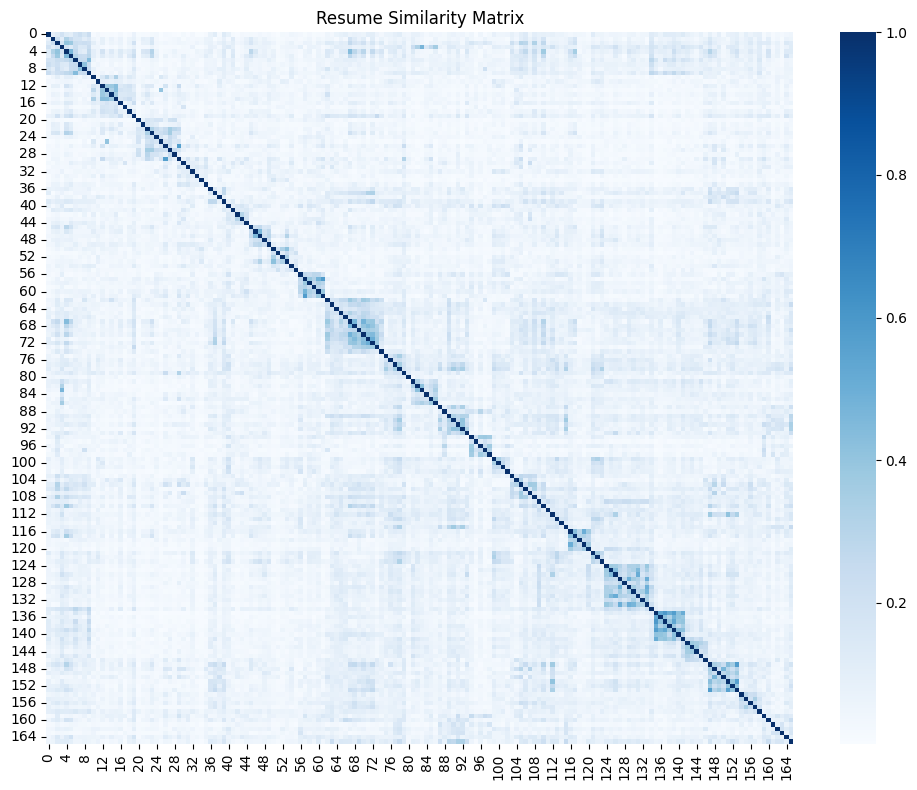

In [66]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    cmap="Blues"
)

plt.title("Resume Similarity Matrix")

plt.tight_layout()

plt.savefig(
    "../images/resume_similarity_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
def find_similar_resume(index):

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    return similarity_scores[1:6]

In [33]:
find_similar_resume(0)

[(9, np.float64(0.2345164049241489)),
 (7, np.float64(0.2207136519155076)),
 (3, np.float64(0.19640690475884914)),
 (6, np.float64(0.17938508154648378)),
 (8, np.float64(0.16875653284413142))]

In [34]:
job_description = """
Looking for a Python Data Scientist with experience in:

Python
Machine Learning
Deep Learning
Pandas
NumPy
Scikit-learn
SQL
Data Analysis
Statistics
Data Visualization
"""

In [35]:
job_vector = tfidf.transform([job_description])

In [36]:
scores = cosine_similarity(job_vector, resume_vectors)

scores.shape

(1, 166)

In [37]:
df["Similarity"] = scores.flatten()

df.head()

,Category,Resume,Resume_Length,Clean_Resume,Similarity
0,Data Science,Skills * Programming Languages: Python (pandas...,4786,skills programming languages python pandas num...,0.206581
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,1268,education details may to may b e uit rgpv data...,0.158077
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871,areas of interest deep learning control system...,0.219039
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,6995,skills â r â python â sap hana â tableau â sap...,0.138835
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",452,education details mca ymcaust faridabad haryan...,0.141120


In [39]:
job_vector = tfidf.transform([job_description])

In [40]:
scores = cosine_similarity(job_vector, resume_vectors)

In [41]:
df["Similarity"] = scores.flatten()

In [42]:
ranking = df.sort_values(
    by="Similarity",
    ascending=False
)

ranking[["Category","Similarity"]].head(10)

,Category,Similarity
6,Data Science,0.414808
8,Data Science,0.376254
7,Data Science,0.353889
9,Data Science,0.299686
2,Data Science,0.219039
0,Data Science,0.206581
556,Python Developer,0.199009
5,Data Science,0.192960
719,Database,0.190833
553,Python Developer,0.185579


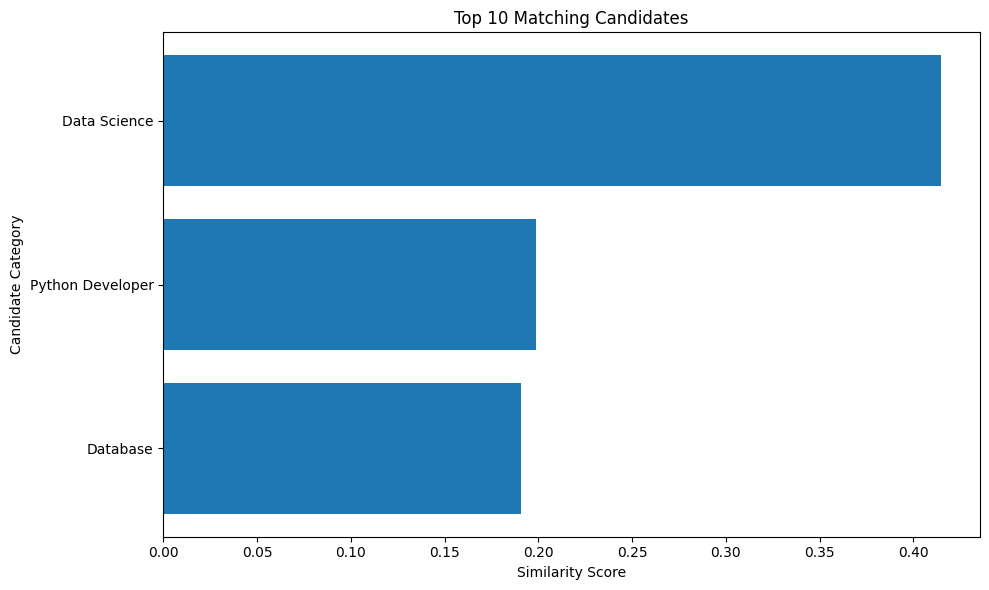

In [61]:
top10 = ranking.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Category"],
    top10["Similarity"]
)

plt.xlabel("Similarity Score")
plt.ylabel("Candidate Category")
plt.title("Top 10 Matching Candidates")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/resume_length_distribution.png", dpi=300)
plt.show()



In [44]:
ranking.head()

,Category,Resume,Resume_Length,Clean_Resume,Similarity
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...,1700,skills â python â tableau â data visualization...,0.414808
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...,1778,personal skills â ability to quickly grasp tec...,0.376254
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,8192,education details b tech rayat and bahra insti...,0.353889
9,Data Science,Expertise â Data and Quantitative Analysis â...,4381,expertise â data and quantitative analysis â d...,0.299686
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871,areas of interest deep learning control system...,0.219039


In [46]:
job_vector = tfidf.transform([job_description])

In [47]:
scores = cosine_similarity(job_vector, resume_vectors)

In [48]:
df["Similarity"] = scores.flatten()

In [49]:
ranking = df.sort_values(
    by="Similarity",
    ascending=False
)

ranking[["Category","Similarity"]].head(10)

,Category,Similarity
6,Data Science,0.414808
8,Data Science,0.376254
7,Data Science,0.353889
9,Data Science,0.299686
2,Data Science,0.219039
0,Data Science,0.206581
556,Python Developer,0.199009
5,Data Science,0.192960
719,Database,0.190833
553,Python Developer,0.185579


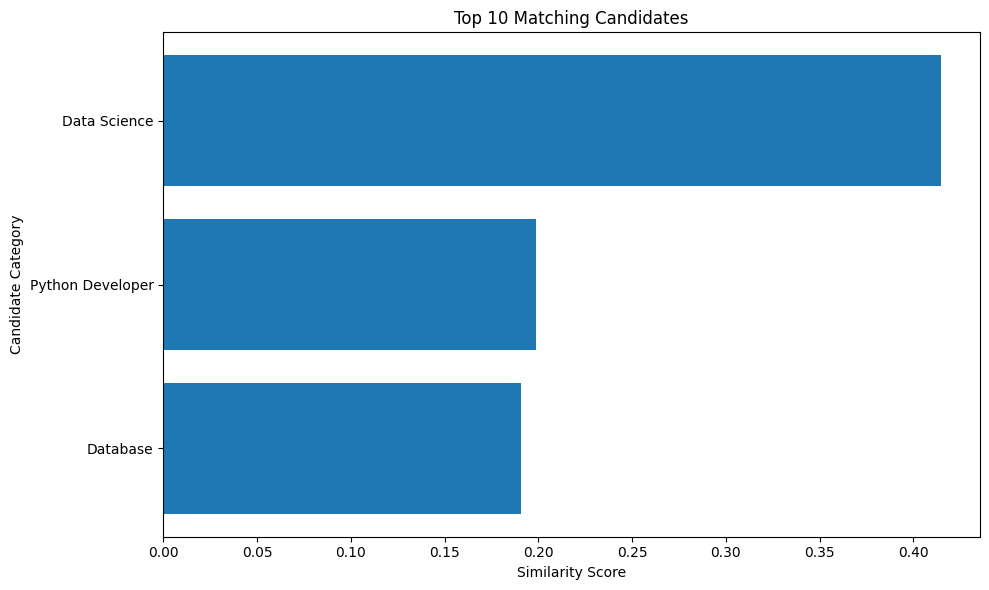

In [62]:
top10 = ranking.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Category"],
    top10["Similarity"]
)

plt.xlabel("Similarity Score")
plt.ylabel("Candidate Category")
plt.title("Top 10 Matching Candidates")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/resume_length_distribution.png", dpi=300)
plt.show()


In [51]:
ranking.head()

,Category,Resume,Resume_Length,Clean_Resume,Similarity
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...,1700,skills â python â tableau â data visualization...,0.414808
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...,1778,personal skills â ability to quickly grasp tec...,0.376254
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...,8192,education details b tech rayat and bahra insti...,0.353889
9,Data Science,Expertise â Data and Quantitative Analysis â...,4381,expertise â data and quantitative analysis â d...,0.299686
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871,areas of interest deep learning control system...,0.219039


In [52]:
ranking = ranking.copy()

ranking["Match_Percentage"] = (
    ranking["Similarity"] * 100
).round(2)

ranking[
    ["Category", "Match_Percentage", "Resume"]
].head(10)

,Category,Match_Percentage,Resume
6,Data Science,41.48,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
8,Data Science,37.63,Personal Skills â¢ Ability to quickly grasp t...
7,Data Science,35.39,Education Details \r\n B.Tech Rayat and Bahr...
9,Data Science,29.97,Expertise â Data and Quantitative Analysis â...
2,Data Science,21.90,"Areas of Interest Deep Learning, Control Syste..."
0,Data Science,20.66,Skills * Programming Languages: Python (pandas...
556,Python Developer,19.90,â¢ Operating Systems: Windows â¢ Others: MS ...
5,Data Science,19.30,"SKILLS C Basics, IOT, Python, MATLAB, Data Sci..."
719,Database,19.08,"TECHNICAL SKILLS â¢ SQL â¢ Oracle v10, v11, ..."
553,Python Developer,18.56,TECHNICAL PROFICIENCIES Platform: Ubuntu/Fedor...


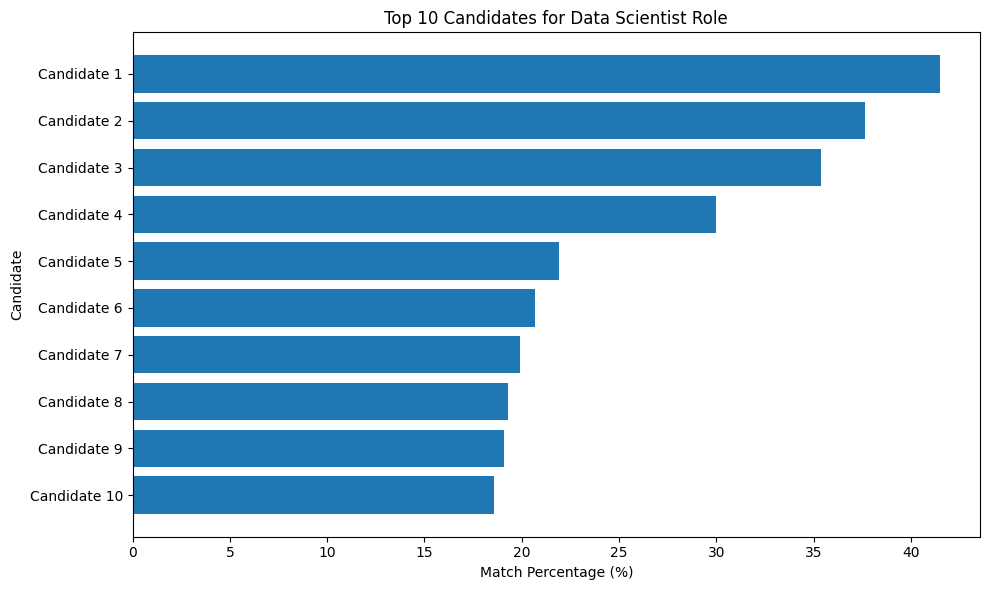

In [63]:
top10 = ranking.head(10).copy()

top10["Candidate"] = [
    f"Candidate {index + 1}"
    for index in range(len(top10))
]

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Candidate"],
    top10["Match_Percentage"]
)

plt.xlabel("Match Percentage (%)")
plt.ylabel("Candidate")
plt.title("Top 10 Candidates for Data Scientist Role")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.tight_layout()
plt.savefig("../images/resume_length_distribution.png", dpi=300)
plt.show()


In [54]:
def rank_candidates(job_description, dataframe, vectorizer, vectors, top_n=10):
    cleaned_job = clean_resume(job_description)

    job_vector = vectorizer.transform([cleaned_job])

    similarity_scores = cosine_similarity(
        job_vector,
        vectors
    ).flatten()

    results = dataframe.copy()
    results["Similarity"] = similarity_scores
    results["Match_Percentage"] = (
        results["Similarity"] * 100
    ).round(2)

    results = results.sort_values(
        by="Similarity",
        ascending=False
    )

    return results.head(top_n)

In [55]:
top_candidates = rank_candidates(
    job_description,
    df,
    tfidf,
    resume_vectors,
    top_n=10
)

top_candidates[
    ["Category", "Match_Percentage"]
]

,Category,Match_Percentage
6,Data Science,41.48
8,Data Science,37.63
7,Data Science,35.39
9,Data Science,29.97
2,Data Science,21.90
0,Data Science,20.66
556,Python Developer,19.90
5,Data Science,19.30
719,Database,19.08
553,Python Developer,18.56


In [56]:
import joblib

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

joblib.dump(resume_vectors, "../models/resume_vectors.pkl")

joblib.dump(df, "../models/resume_dataframe.pkl")

print("Model files saved successfully!")

Model files saved successfully!


In [57]:
# # Conclusion

# The Resume Screening System successfully ranks resumes based on their similarity to a given job description.

# Main achievements:
# - Loaded and explored the resume dataset
# - Cleaned and preprocessed resume text
# - Converted resumes into TF-IDF vectors
# - Compared resumes with a job description using cosine similarity
# - Ranked candidates according to similarity score
# - Visualized the top matching candidates

# This project demonstrates a simple AI-powered resume screening system that can assist recruiters during the initial candidate selection process.

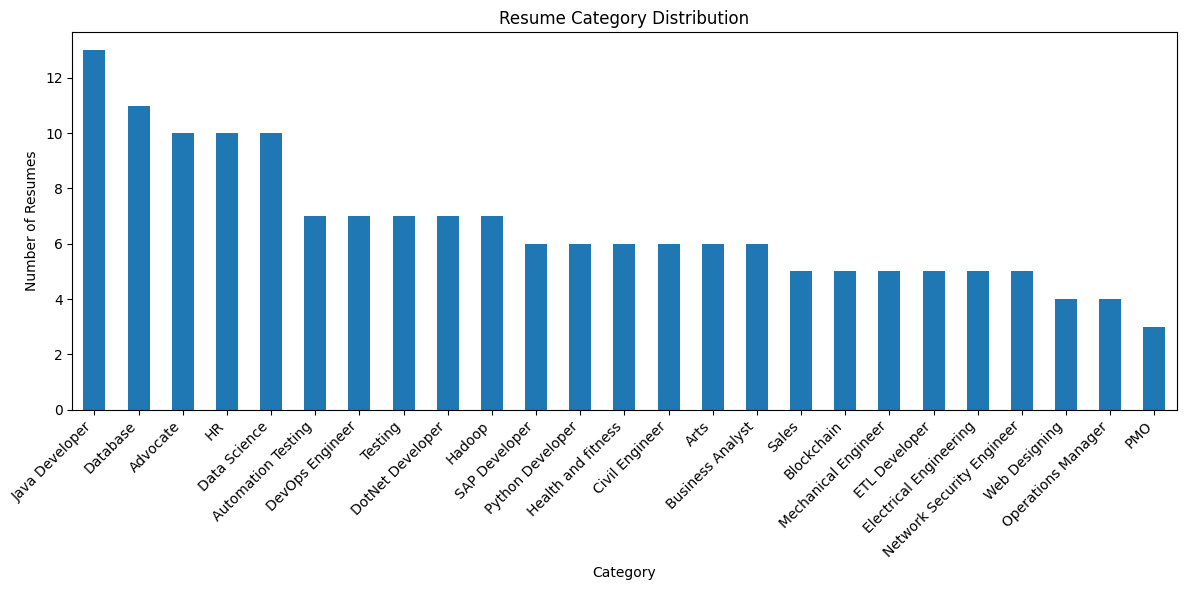

In [65]:
plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("../images/category_distribution.png", dpi=300)

plt.show()